In [1]:
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "lonboard", "ipywidgets", "matplotlib"])
from pathlib import Path
import pandas as pd
import geopandas as gpd


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [2]:
from pathlib import Path
base = Path().resolve()
while not (base / "readme.md").exists() and base != base.parent:
    base = base.parent

print("base:", base)
for f in base.rglob("*.csv"):
    print(f.relative_to(base))

base: /Users/rohanlalla/Documents/GitHub/nycha
data/processed/combined_steam_2024.csv
data/processed/nycha_residential.csv
data/processed/cleaned_nycha.csv
data/processed/cleaned_PLUTO.csv
data/processed/combined_utilities_2024.csv
data/processed/combined_heating_gas_2024.csv
data/processed/combined_electricity_2024.csv
data/processed/combined_nychares_pluto.csv
data/raw/Heating_Gas_Consumption_And_Cost_(2010_-__Sep_2025)_20260314.csv
data/raw/Steam_Consumption_And_Cost_(2010_–_Sep_2025)_20260314.csv
data/raw/NYCHA_Residential_Addresses_20260314.csv
data/raw/Primary_Land_Use_Tax_Lot_Output_(PLUTO)_20260314.csv
data/raw/Electric_Consumption_And_Cost_(2010_-_Sep_2025)_20260314.csv
data/raw/NYCHA_Development_Data_Book_20260314.csv


In [4]:
import pandas as pd
from pathlib import Path

# Find the repo root by looking for readme.md
base = Path().resolve()
while not (base / "readme.md").exists() and base != base.parent:
    base = base.parent

# Read csv

utilities = pd.read_csv(base / "data/processed/combined_utilities_2024.csv")
ddb       = pd.read_csv(base / "data/raw/NYCHA_Development_Data_Book_20260314.csv")

# Clean ddb data

ddb_apts = ddb[['TDS#', 'CONSOLIDATED TDS#', 'TOTAL NUMBER OF APARTMENTS']].copy()
ddb_apts['tds_#'] = (
    ddb_apts['TDS#']
    .str.replace(r'\*', '', regex=True)
    .str.split(',').str[0]
    .fillna(ddb_apts['CONSOLIDATED TDS#'])
    .str.strip()
)
ddb_apts['tds_#'] = pd.to_numeric(ddb_apts['tds_#'], errors='coerce')
ddb_apts = ddb_apts.dropna(subset=['tds_#'])
ddb_apts['tds_#'] = ddb_apts['tds_#'].astype(int)
ddb_apts['ddb_apartments'] = pd.to_numeric(
    ddb_apts['TOTAL NUMBER OF APARTMENTS'].str.replace(',', ''), errors='coerce'
)
ddb_apts = ddb_apts[['tds_#', 'ddb_apartments']]

# Merge data

utilities = utilities.merge(ddb_apts, on='tds_#', how='left')


print(f"Unmatched rows: {utilities['ddb_apartments'].isna().sum()}")

Unmatched rows: 0


In [6]:
import numpy as np
from shapely.geometry import Point
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pyarrow", "folium"])


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


CompletedProcess(args=['/opt/homebrew/opt/python@3.11/bin/python3.11', '-m', 'pip', 'install', 'pyarrow', 'folium'], returncode=0)

In [7]:
# Create grouped dataframe with cost data

df_grouped = utilities.groupby(['tds_#', 'development'], as_index=False).apply(
    lambda g: pd.Series({
        'ddb_apartments':               g['ddb_apartments'].iloc[0],
        'steam_current_charges':        g['steam_current_charges'].iloc[0],
        'gas_current_charges':          g['gas_current_charges'].iloc[0],
        'electricity_current_charges':  g['electricity_current_charges'].iloc[0],
        'latitude_nycha':               g['latitude_nycha'].iloc[0],
        'longitude_nycha':              g['longitude_nycha'].iloc[0],
    }),
    include_groups=False
).reset_index(drop=True)

# Filter zero/missing units
df_grouped = df_grouped[df_grouped['ddb_apartments'] > 0]

# Calculate per-unit costs
df_grouped['total_current_charges'] = (
    df_grouped['steam_current_charges'].fillna(0) +
    df_grouped['gas_current_charges'].fillna(0) +
    df_grouped['electricity_current_charges'].fillna(0)
)
df_grouped['total_current_charges_per_unit'] = df_grouped['total_current_charges']       / df_grouped['ddb_apartments']
df_grouped['steam_cost_per_unit']            = df_grouped['steam_current_charges']        / df_grouped['ddb_apartments']
df_grouped['gas_cost_per_unit']              = df_grouped['gas_current_charges']          / df_grouped['ddb_apartments']
df_grouped['elec_cost_per_unit']             = df_grouped['electricity_current_charges']  / df_grouped['ddb_apartments']

top20 = df_grouped.nlargest(20, 'total_current_charges_per_unit').sort_values(
    'total_current_charges_per_unit', ascending=True)

print(top20[['tds_#', 'development', 'ddb_apartments', 'total_current_charges_per_unit']].tail(10))

     tds_#                         development  ddb_apartments  \
108    136                              FULTON           944.0   
134    173   WSUR (SITE B) 74 WEST 92ND STREET           168.0   
87     100                             GOMPERS           474.0   
117    151  WSUR (SITE A) 120 WEST 94TH STREET            70.0   
52      60                              BARUCH          2194.0   
143    187                  AMSTERDAM ADDITION           175.0   
44      51    OCEAN BAY APARTMENTS (OCEANSIDE)           418.0   
8       11                CLASON POINT GARDENS           401.0   
71      79                       RED HOOK WEST           346.0   
164    239            CONEY ISLAND I (SITE 1B)           193.0   

     total_current_charges_per_unit  
108                     3874.911028  
134                     3959.487381  
87                      4078.965865  
117                     4223.174143  
52                      4250.143377  
143                     4507.581943  
44     

In [8]:
import folium
from pathlib import Path

costs = top20['total_current_charges_per_unit'].values
cost_min, cost_max = costs.min(), costs.max()

def cost_to_color(cost):
    n = (cost - cost_min) / (cost_max - cost_min)
    g = int(255 * (1 - n))
    return f'#ff{g:02x}00'

m = folium.Map(location=[40.728, -73.944], zoom_start=11, tiles='CartoDB dark_matter')

for _, row in top20.iterrows():
    n = (row['total_current_charges_per_unit'] - cost_min) / (cost_max - cost_min)
    folium.CircleMarker(
        location=[row['latitude_nycha'], row['longitude_nycha']],
        radius=8 + n * 15,
        color=cost_to_color(row['total_current_charges_per_unit']),
        fill=True,
        fill_color=cost_to_color(row['total_current_charges_per_unit']),
        fill_opacity=0.85,
        tooltip=(
            f"<b>{row['development']}</b><br>"
            f"TDS#: {row['tds_#']}<br>"
            f"Units: {int(row['ddb_apartments'])}<br>"
            f"Cost/unit: ${row['total_current_charges_per_unit']:,.0f}<br>"
            f"Total charges: ${row['total_current_charges']:,.0f}"
        )
    ).add_to(m)

output_dir = base / "output"
output_dir.mkdir(parents=True, exist_ok=True)
m.save(output_dir / "nycha_top20_cost_map.html")
print(f"Saved to {output_dir / 'nycha_top20_cost_map.html'}")

Saved to /Users/rohanlalla/Documents/GitHub/nycha/output/nycha_top20_cost_map.html


In [9]:
# Replicate  how Emma's notebook calculated mmbtu
utilities['steam_mmbtu_per_unit']       = utilities['steam_consumption_per_unit']
utilities['gas_mmbtu_per_unit']         = utilities['gas_consumption_per_unit'] / 10
utilities['electricity_mmbtu_per_unit'] = utilities['electricity_consumption_per_unit'] / 293
utilities['total_energy_mmbtu_per_unit'] = (
    utilities['steam_mmbtu_per_unit'].fillna(0) +
    utilities['gas_mmbtu_per_unit'].fillna(0) +
    utilities['electricity_mmbtu_per_unit'].fillna(0)
)

# Weighted average by unitsres across buildings in each TDS
df_grouped = utilities.groupby(['tds_#', 'development'], as_index=False).apply(
    lambda g: pd.Series({
        'ddb_apartments':              g['ddb_apartments'].iloc[0],
        'steam_current_charges':       g['steam_current_charges'].iloc[0],
        'gas_current_charges':         g['gas_current_charges'].iloc[0],
        'electricity_current_charges': g['electricity_current_charges'].iloc[0],
        'total_energy_mmbtu_per_unit': (
            (g['total_energy_mmbtu_per_unit'] * g['unitsres']).sum() /
            g['unitsres'].sum()
        ) if g['unitsres'].notna().any() else g['total_energy_mmbtu_per_unit'].mean(),
        'latitude_nycha':              g['latitude_nycha'].iloc[0],
        'longitude_nycha':             g['longitude_nycha'].iloc[0],
    }),
    include_groups=False
).reset_index(drop=True)

df_grouped = df_grouped[df_grouped['ddb_apartments'] > 0]

df_grouped['total_current_charges'] = (
    df_grouped['steam_current_charges'].fillna(0) +
    df_grouped['gas_current_charges'].fillna(0) +
    df_grouped['electricity_current_charges'].fillna(0)
)
df_grouped['total_current_charges_per_unit'] = df_grouped['total_current_charges'] / df_grouped['ddb_apartments']

top20_consumption = df_grouped.nlargest(20, 'total_energy_mmbtu_per_unit').sort_values(
    'total_energy_mmbtu_per_unit', ascending=True)

print(top20_consumption[['tds_#', 'development', 'ddb_apartments',
                          'total_energy_mmbtu_per_unit']].tail(5))

     tds_#                        development  ddb_apartments  \
164    239           CONEY ISLAND I (SITE 1B)           193.0   
58      66                   SOUTH JAMAICA II           600.0   
186    283  FHA REPOSSESSED HOUSES (GROUP IX)            27.0   
108    136                             FULTON           944.0   
206    367           HUNTS POINT AVENUE REHAB           131.0   

     total_energy_mmbtu_per_unit  
164                   832.152890  
58                    968.934471  
186                   974.144846  
108                  1217.921731  
206                  1311.997337  


In [10]:
# Build consumption map

consumption = top20_consumption['total_energy_mmbtu_per_unit'].values
con_min, con_max = consumption.min(), consumption.max()

def consumption_to_color(val):
    n = (val - con_min) / (con_max - con_min)
    g = int(255 * (1 - n))
    return f'#ff{g:02x}00'

m = folium.Map(location=[40.728, -73.944], zoom_start=11, tiles='CartoDB dark_matter')

for _, row in top20_consumption.iterrows():
    n = (row['total_energy_mmbtu_per_unit'] - con_min) / (con_max - con_min)
    total_mmbtu = row['total_energy_mmbtu_per_unit'] * row['ddb_apartments']
    tooltip_html = (
        f"<b>{row['development']}</b><br>"
        f"TDS#: {row['tds_#']}<br>"
        f"Units: {int(row['ddb_apartments'])}<br>"
        f"MMBtu/unit: {row['total_energy_mmbtu_per_unit']:,.1f}<br>"
        f"Total MMBtu: {total_mmbtu:,.0f}"
    )
    folium.CircleMarker(
        location=[row['latitude_nycha'], row['longitude_nycha']],
        radius=8 + n * 15,
        color=consumption_to_color(row['total_energy_mmbtu_per_unit']),
        fill=True,
        fill_color=consumption_to_color(row['total_energy_mmbtu_per_unit']),
        fill_opacity=0.85,
        tooltip=tooltip_html
    ).add_to(m)

output_dir = base / "output"
output_dir.mkdir(parents=True, exist_ok=True)
m.save(output_dir / "nycha_top20_consumption_map.html")
print(f"Saved to {output_dir / 'nycha_top20_consumption_map.html'}")

Saved to /Users/rohanlalla/Documents/GitHub/nycha/output/nycha_top20_consumption_map.html


In [11]:
# Create scatterplot
# Read cleaned pluto csv
base = Path().resolve()
while not (base / "readme.md").exists() and base != base.parent:
    base = base.parent

yearbuilt_df = pd.read_csv(base / "data/processed/combined_nychares_pluto.csv")

In [12]:
print(yearbuilt_df.columns.tolist())

['development', 'tds_#', 'building_#', 'stairhall#', 'borough_nycha', 'house_#', 'street', 'address_nycha', 'city', 'state', 'zip_code', 'bin', 'block', 'lot', 'BBL', 'census_tract_(2020)', 'neighborhood_tabulation_area_code', 'neighborhood_tabulation_area_name', 'community_district', 'city_council_district', 'state_assembly_district', 'state_senate_district', 'us_congressional_district', 'privately_managed', 'latitude_nycha', 'longitude_nycha', 'geometry', 'borough_pluto', 'tax_block', 'tax_lot', 'census_tract_2010', 'cb2010', 'council_district', 'postcode', 'policeprct', 'healtharea', 'address_pluto', 'zonedist1', 'zonedist2', 'zonedist3', 'zonedist4', 'ltdheight', 'bldgclass', 'landuse', 'easements', 'ownertype', 'ownername', 'lotarea', 'bldgarea', 'resarea', 'garagearea', 'strgearea', 'otherarea', 'areasource', 'numbldgs', 'numfloors', 'unitsres', 'unitstotal', 'lotfront', 'lotdepth', 'bldgfront', 'bldgdepth', 'proxcode', 'irrlotcode', 'lottype', 'assessland', 'assesstot', 'yearbui

In [13]:
# Merge with consumption data
combined_df =  yearbuilt_df.merge(utilities, on='tds_#', how='left')

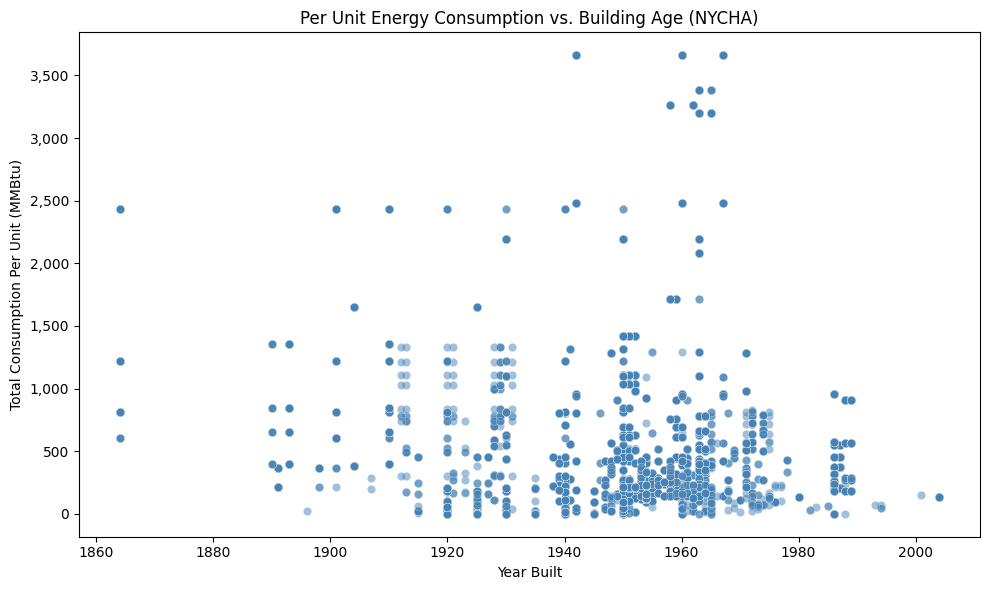

In [14]:
import matplotlib.pyplot as plt

# Build scatterplot
fig, ax = plt.subplots(figsize=(10, 6))

scatter_df = combined_df.dropna(subset=['yearbuilt', 'total_energy_mmbtu_per_unit'])
scatter_df = scatter_df[scatter_df['yearbuilt'] > 0]  # drop placeholder 0s

ax.scatter(scatter_df['yearbuilt'], scatter_df['total_energy_mmbtu_per_unit'],
           alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3)

ax.set_xlabel('Year Built')
ax.set_ylabel('Total Consumption Per Unit (MMBtu)')
ax.set_title('Per Unit Energy Consumption vs. Building Age (NYCHA)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()